<a href="https://colab.research.google.com/github/KarAnalytics/code_demos/blob/main/Image_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAG with Images: Image Retrieval and Multimodal Q&A

This notebook demonstrates **Retrieval-Augmented Generation (RAG)** where the knowledge source is a collection of **images** rather than text documents or a database.

**How it works:**
1. Build a small image dataset (synthetic product catalog images generated in-notebook — no external data needed).
2. Compute **CLIP embeddings** for each image to create a searchable vector index.
3. Given a natural-language query, compute a **text embedding** and retrieve the most relevant images.
4. Send the retrieved images to a **multimodal LLM** which generates a grounded, natural-language answer.

**Learning goals:**
- Understand how RAG extends to visual/multimodal data
- See how CLIP jointly embeds text and images into a shared vector space
- Practice grounding LLM output on retrieved image evidence
- Compare answers with and without image context

**Provider setup:** Gemini is tried first; if quota is exhausted, Ollama Cloud is used automatically.  
Store your LLM API keys in Colab Secrets (or a local `.env` file). Supported keys: `GEMINI_API_KEY`, `OPENAI_API_KEY`, `GROQ_API_KEY`, `HF_TOKEN`, `COHERE_API_KEY`, `XAI_API_KEY`, `OLLAMA_API_KEY`, `OPENROUTER_API_KEY`.

In [1]:
!pip install -q google-genai Pillow==11.0.0 transformers==4.46.3 git+https://github.com/KarAnalytics/llm_cascade.git


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 59.8 MB/s eta 0:00:00


## 1) Imports and Provider Helpers

We use **CLIP** (from Hugging Face `transformers`) to embed images and text into the same vector space, and **PIL/Pillow** for image handling.

The provider helpers below follow the same pattern used in the DBMS RAG notebook:
Gemini first, Ollama Cloud fallback, keys from Colab Secrets or `.env`.

In [2]:
import os
import base64
import io
import json
import numpy as np
from pathlib import Path

from PIL import Image, ImageDraw, ImageFont
from google import genai
from google.genai import types as genai_types

from llm_cascade import get_cascade
from llm_cascade.providers import _get_key

llm = get_cascade()


def generate_text(prompt, system_prompt=None, **kwargs):
    response = llm.generate(prompt, system_prompt=system_prompt)
    return response.text, response.provider


def has_llm_provider():
    return True  # llm_cascade auto-detects available providers


def get_gemini_api_key():
    return _get_key("GEMINI_API_KEY")


def is_gemini_quota_error(exc):
    msg = str(exc).lower()
    return any(s in msg for s in ("quota", "resource_exhausted", "429", "rate limit", "exceeded your current quota"))


print("Provider ready (llm_cascade + Gemini multimodal)")


LLM Cascade - available providers:
  + Gemini           model=gemini-2.5-flash
  + Ollama           model=kimi-k2.5:cloud
  + Groq             model=llama-3.3-70b-versatile
  + HuggingFace      model=meta-llama/Llama-3.3-70B-Instruct
  + Cohere           model=command-a-03-2025
  + OpenRouter       model=meta-llama/llama-3.3-70b-instruct:free
  + OpenAI           model=gpt-4o-mini
Not configured (skipped):
  - Grok (xAI)       (set XAI_API_KEY)
Provider ready (llm_cascade + Gemini multimodal)


## 2) Generate a Synthetic Image Dataset

Since we do not have external image data, we create a small **synthetic product catalog** consisting of simple colored shapes with labels. Each image represents a product with specific visual attributes (shape, color, size, pattern).

This keeps the demo self-contained while illustrating the full Image RAG pipeline.

| Product | Shape | Color | Pattern |
|---|---|---|---|
| Widget A | Circle | Red | Solid |
| Widget B | Square | Blue | Striped |
| Gadget X | Triangle | Green | Solid |
| Gadget Y | Circle | Yellow | Dotted |
| Tool M | Rectangle | Purple | Solid |
| Tool N | Diamond | Orange | Striped |

In [3]:
import math

# --- Product catalog definition ---
PRODUCTS = [
    {"name": "Widget A", "shape": "circle",    "color": "#E74C3C", "color_name": "red",    "pattern": "solid",   "price": 12.99, "category": "widgets"},
    {"name": "Widget B", "shape": "square",    "color": "#3498DB", "color_name": "blue",   "pattern": "striped", "price": 24.50, "category": "widgets"},
    {"name": "Gadget X", "shape": "triangle",  "color": "#2ECC71", "color_name": "green",  "pattern": "solid",   "price": 8.75,  "category": "gadgets"},
    {"name": "Gadget Y", "shape": "circle",    "color": "#F1C40F", "color_name": "yellow", "pattern": "dotted",  "price": 15.00, "category": "gadgets"},
    {"name": "Tool M",   "shape": "rectangle", "color": "#9B59B6", "color_name": "purple", "pattern": "solid",   "price": 34.99, "category": "tools"},
    {"name": "Tool N",   "shape": "diamond",   "color": "#E67E22", "color_name": "orange", "pattern": "striped", "price": 19.25, "category": "tools"},
    {"name": "Widget C", "shape": "circle",    "color": "#1ABC9C", "color_name": "teal",   "pattern": "solid",   "price": 11.50, "category": "widgets"},
    {"name": "Gadget Z", "shape": "square",    "color": "#E91E63", "color_name": "pink",   "pattern": "dotted",  "price": 29.99, "category": "gadgets"},
]


def draw_product_image(product, size=256):
    """Generate a synthetic product image with shape, color, pattern, and label."""
    img = Image.new("RGB", (size, size), "white")
    draw = ImageDraw.Draw(img)
    margin = 40
    cx, cy = size // 2, size // 2
    r = size // 2 - margin  # radius or half-size

    color = product["color"]
    shape = product["shape"]

    # Draw the shape
    if shape == "circle":
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=color, outline="black", width=2)
    elif shape == "square":
        draw.rectangle([cx - r, cy - r, cx + r, cy + r], fill=color, outline="black", width=2)
    elif shape == "rectangle":
        draw.rectangle([cx - r, cy - r // 2, cx + r, cy + r // 2], fill=color, outline="black", width=2)
    elif shape == "triangle":
        points = [(cx, cy - r), (cx - r, cy + r), (cx + r, cy + r)]
        draw.polygon(points, fill=color, outline="black", width=2)
    elif shape == "diamond":
        points = [(cx, cy - r), (cx + r, cy), (cx, cy + r), (cx - r, cy)]
        draw.polygon(points, fill=color, outline="black", width=2)

    # Add pattern overlay
    if product["pattern"] == "striped":
        for y in range(0, size, 12):
            draw.line([(0, y), (size, y)], fill="white", width=2)
    elif product["pattern"] == "dotted":
        for dx in range(margin, size - margin, 20):
            for dy in range(margin, size - margin, 20):
                draw.ellipse([dx - 3, dy - 3, dx + 3, dy + 3], fill="white")

    # Add product name label at top
    try:
        font = ImageFont.truetype("arial.ttf", 16)
    except (OSError, IOError):
        font = ImageFont.load_default()
    bbox = draw.textbbox((0, 0), product["name"], font=font)
    tw = bbox[2] - bbox[0]
    draw.text(((size - tw) // 2, 5), product["name"], fill="black", font=font)

    # Add price label at bottom
    price_text = f"${product['price']:.2f}"
    bbox = draw.textbbox((0, 0), price_text, font=font)
    tw = bbox[2] - bbox[0]
    draw.text(((size - tw) // 2, size - 25), price_text, fill="black", font=font)

    return img


# Generate and save all product images
IMAGE_DIR = Path("product_images")
IMAGE_DIR.mkdir(exist_ok=True)

image_paths = []
for product in PRODUCTS:
    img = draw_product_image(product)
    filename = product["name"].lower().replace(" ", "_") + ".png"
    path = IMAGE_DIR / filename
    img.save(path)
    image_paths.append(path)

print(f"Generated {len(image_paths)} product images in '{IMAGE_DIR}/'")
print("Files:", [p.name for p in image_paths])

Generated 8 product images in 'product_images/'
Files: ['widget_a.png', 'widget_b.png', 'gadget_x.png', 'gadget_y.png', 'tool_m.png', 'tool_n.png', 'widget_c.png', 'gadget_z.png']


### Preview the Generated Images

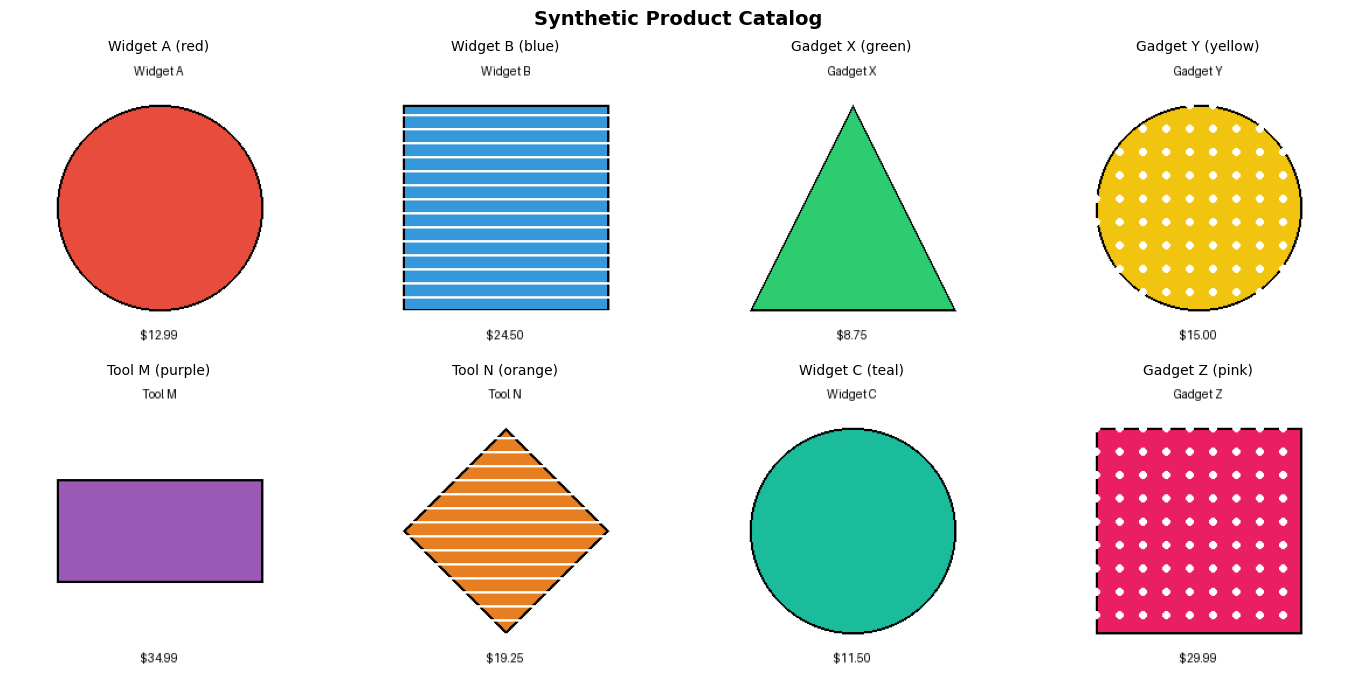

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, product, path in zip(axes.flat, PRODUCTS, image_paths):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(f"{product['name']} ({product['color_name']})", fontsize=10)
    ax.axis("off")
plt.suptitle("Synthetic Product Catalog", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3) Build the Image Index with CLIP Embeddings

**CLIP** (Contrastive Language-Image Pre-training) maps both text and images into the **same vector space**. This is the key enabling technology for Image RAG:

- We compute an embedding for each product image.
- At query time, we embed the user's text query with the same model.
- We retrieve images whose embeddings are closest to the query embedding.

This is analogous to how ChromaDB uses text embeddings in document RAG, but here we work across modalities.

In [5]:
from transformers import CLIPProcessor, CLIPModel
import torch

# Load CLIP model (downloads ~600 MB on first run)
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)

print(f"CLIP model loaded: {CLIP_MODEL_NAME}")
print(f"Embedding dimension: {clip_model.config.projection_dim}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded: openai/clip-vit-base-patch32
Embedding dimension: 512


In [7]:
def embed_images(image_paths, model, processor):
    """Compute CLIP embeddings for a list of image files."""
    images = [Image.open(p).convert("RGB") for p in image_paths]
    inputs = processor(images=images, return_tensors="pt", padding=True)
    with torch.no_grad():
        embeddings = model.get_image_features(**inputs)
    # Normalize to unit vectors for cosine similarity
    embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
    return embeddings.numpy()


def embed_text(query, model, processor):
    """Compute CLIP embedding for a text query."""
    inputs = processor(text=[query], return_tensors="pt", padding=True, truncation=True)
    with torch.no_grad():
        embeddings = model.get_text_features(**inputs)
    embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
    return embeddings.numpy()


# Build the image index
image_embeddings = embed_images(image_paths, clip_model, clip_processor)
print(f"Image index built: {image_embeddings.shape[0]} images, {image_embeddings.shape[1]}-dim embeddings")

Image index built: 8 images, 512-dim embeddings


## 4) Image Retrieval — the "Retrieval" in Image RAG

Given a text query, we:
1. Embed the query with CLIP's text encoder.
2. Compute **cosine similarity** between the query embedding and all image embeddings.
3. Return the top-k most similar images.

This is the image equivalent of vector similarity search in document RAG.

In [8]:
def retrieve_images(query, image_embeddings, image_paths, products, model, processor, top_k=3):
    """Retrieve the top-k most relevant images for a text query."""
    query_emb = embed_text(query, model, processor)
    # Cosine similarity (embeddings are already normalized)
    similarities = (query_emb @ image_embeddings.T).flatten()
    # Get top-k indices
    top_indices = similarities.argsort()[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "rank": len(results) + 1,
            "product": products[idx],
            "path": image_paths[idx],
            "similarity": float(similarities[idx]),
        })
    return results


# Test retrieval
test_query = "red circular product"
results = retrieve_images(test_query, image_embeddings, image_paths, PRODUCTS, clip_model, clip_processor)

print(f"Query: '{test_query}'\n")
for r in results:
    print(f"  #{r['rank']} {r['product']['name']} "
          f"({r['product']['color_name']} {r['product']['shape']}) "
          f"— similarity: {r['similarity']:.4f}")

Query: 'red circular product'

  #1 Gadget Z (pink square) — similarity: 0.2663
  #2 Widget A (red circle) — similarity: 0.2639
  #3 Gadget Y (yellow circle) — similarity: 0.2633


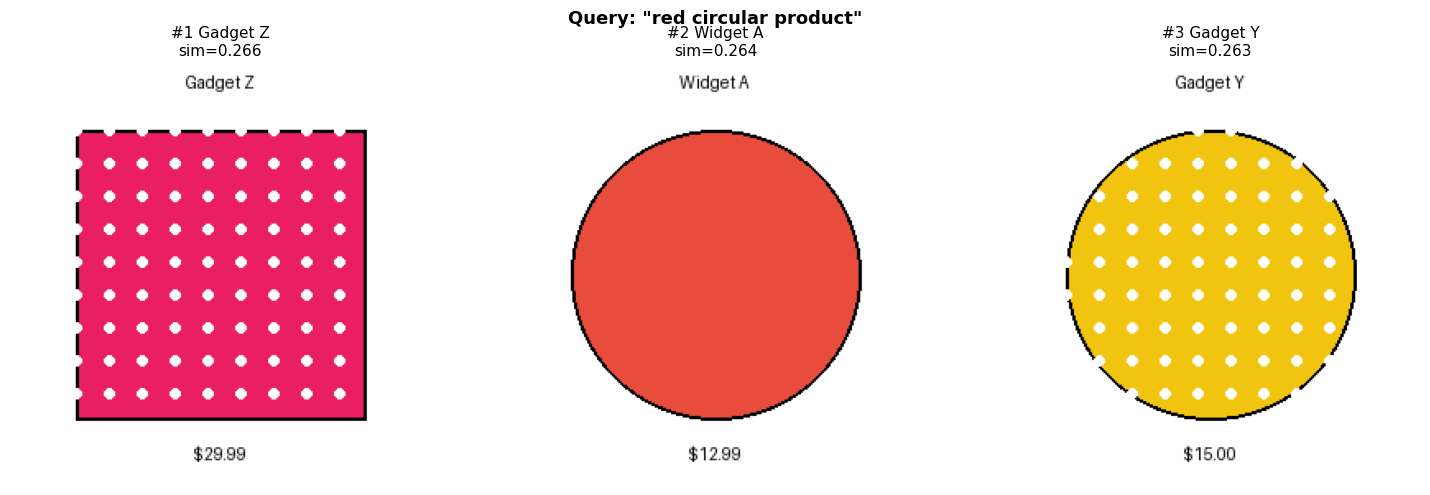

In [9]:
# Visualize retrieval results
def show_retrieval_results(query, results):
    """Display retrieved images side by side."""
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, r in zip(axes, results):
        img = Image.open(r["path"])
        ax.imshow(img)
        ax.set_title(f"#{r['rank']} {r['product']['name']}\nsim={r['similarity']:.3f}", fontsize=11)
        ax.axis("off")
    fig.suptitle(f"Query: \"{query}\"", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


show_retrieval_results(test_query, results)

## 5) Multimodal Answer Generation

This is the core RAG step: the multimodal LLM receives the **retrieved images** along with **product metadata** and the user's question, then generates a grounded answer.

We send images as base64-encoded data to the Gemini or Ollama API.

**Note:** If the LLM provider does not support vision (e.g., a text-only Ollama model), we fall back to sending the product metadata as text context.

In [10]:
def image_to_base64(image_path):
    """Convert an image file to a base64 string."""
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


def build_metadata_context(results):
    """Build a text description of retrieved products for text-only fallback."""
    lines = ["Retrieved products (ranked by visual similarity):"]
    for r in results:
        p = r["product"]
        lines.append(
            f"  #{r['rank']} {p['name']}: {p['color_name']} {p['shape']}, "
            f"{p['pattern']} pattern, ${p['price']:.2f}, category={p['category']} "
            f"(similarity={r['similarity']:.3f})"
        )
    return "\n".join(lines)


ANSWER_SYSTEM_PROMPT = (
    "You are a helpful product catalog assistant. Use ONLY the provided images and "
    "product metadata to answer the user's question. If the retrieved products do not "
    "contain enough information, say so. Do not invent products that are not shown."
)


def generate_multimodal_answer(question, results, gemini_model="gemini-2.5-flash", **kwargs):
    """Send retrieved images + metadata to a multimodal LLM for a grounded answer."""
    metadata_text = build_metadata_context(results)
    gemini_key = get_gemini_api_key()

    # --- Try Gemini (native multimodal) ---
    if gemini_key:
        try:
            client = genai.Client(api_key=gemini_key)
            parts = []
            parts.append(genai_types.Part.from_text(
                text=f"{ANSWER_SYSTEM_PROMPT}\n\n{metadata_text}\n\nQUESTION: {question}"
            ))
            for r in results:
                img_bytes = Path(r["path"]).read_bytes()
                parts.append(genai_types.Part.from_bytes(
                    data=img_bytes,
                    mime_type="image/png",
                ))

            resp = client.models.generate_content(
                model=gemini_model,
                contents=parts,
            )
            return resp.text, "gemini"
        except Exception as exc:
            if not is_gemini_quota_error(exc):
                raise
            print("Gemini quota exhausted. Falling back to text-only LLM cascade ...")

    # --- Fallback: text-only via llm_cascade ---
    prompt = f"{metadata_text}\n\nQUESTION: {question}"
    response = llm.generate(prompt, system_prompt=ANSWER_SYSTEM_PROMPT)
    return response.text, response.provider


print("Multimodal answer generation ready.")


Multimodal answer generation ready.


## 6) Full Image RAG Pipeline

Putting it all together: retrieve relevant images, then generate a grounded answer.

We also provide a "without RAG" baseline where the LLM answers with no image context.

In [11]:
def answer_with_image_rag(question, top_k=3, gemini_model="gemini-2.5-flash", **kwargs):
    """Full Image RAG pipeline: embed query -> retrieve images -> multimodal answer."""
    print(f"  [Step 1] Embedding query with CLIP ...")
    results = retrieve_images(
        question, image_embeddings, image_paths, PRODUCTS,
        clip_model, clip_processor, top_k=top_k,
    )
    print(f"  [Step 2] Retrieved {len(results)} images:")
    for r in results:
        print(f"           #{r['rank']} {r['product']['name']} (sim={r['similarity']:.3f})")

    print(f"  [Step 3] Generating multimodal answer ...")
    answer, provider = generate_multimodal_answer(
        question, results,
        gemini_model=gemini_model,
    )
    print(f"  [Step 4] Answer generated (provider: {provider})")

    return answer, results, provider


def answer_without_rag(question, **kwargs):
    """Direct LLM answer with no image context."""
    answer, provider = generate_text(prompt=question)
    return answer, provider


print("Full Image RAG pipeline ready.")


Full Image RAG pipeline ready.


## 7) Run End-to-End Examples

We test several questions and compare:
- **With Image RAG:** CLIP retrieval + multimodal grounded answer
- **Without RAG:** direct LLM answer (no product images or metadata)

Watch for hallucinations in the "without RAG" answers — the model has no access to our product catalog.


Q1. What red products do you have?

  [Step 1] Embedding query with CLIP ...
  [Step 2] Retrieved 3 images:
           #1 Widget A (sim=0.238)
           #2 Gadget Z (sim=0.230)
           #3 Tool N (sim=0.229)
  [Step 3] Generating multimodal answer ...
  [Step 4] Answer generated (provider: gemini)


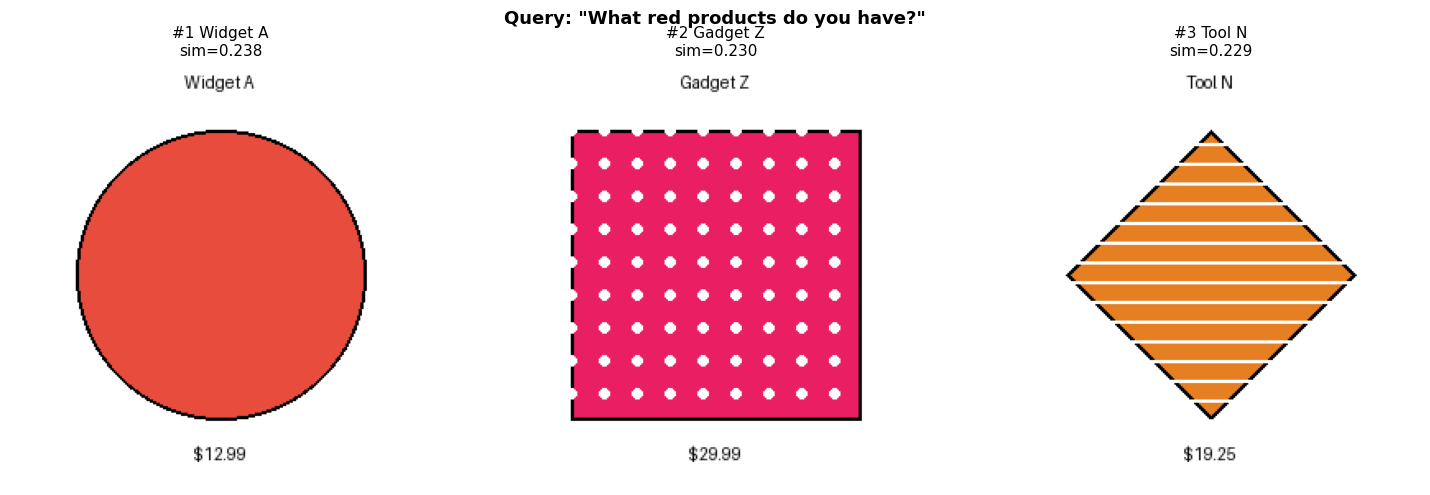


  [WITH IMAGE RAG]
We have the following red product:

*   **Widget A**: a red circle with a solid pattern, priced at $12.99. It is a widget.
  [Response from Gemini / gemini-2.5-flash]

  [WITHOUT RAG] (provider: Gemini)
As an AI, I don't actually "have" products in a physical sense, nor do I sell anything. However, I can certainly help you brainstorm or find examples of products that come in red across many different categories!

Are you looking for red products in a specific area? For example:

*   **Fashion & Apparel:** Red dresses, shirts, shoes, handbags, scarves, ties, lingerie, athletic wear.
*   **Electronics:** Red smartphones, headphones, speakers, blenders, toasters, stand mixers, small appliances.
*   **Home Goods & Decor:** Red paint, furniture (sofas, chairs), throw pillows, blankets, kitchenware (pots, pans, dishes), towels, rugs, decorative items.
*   **Beauty & Cosmetics:** Red lipstick, nail polish, hair dye.
*   **Automotive:** Red cars, motorcycles, car interiors,

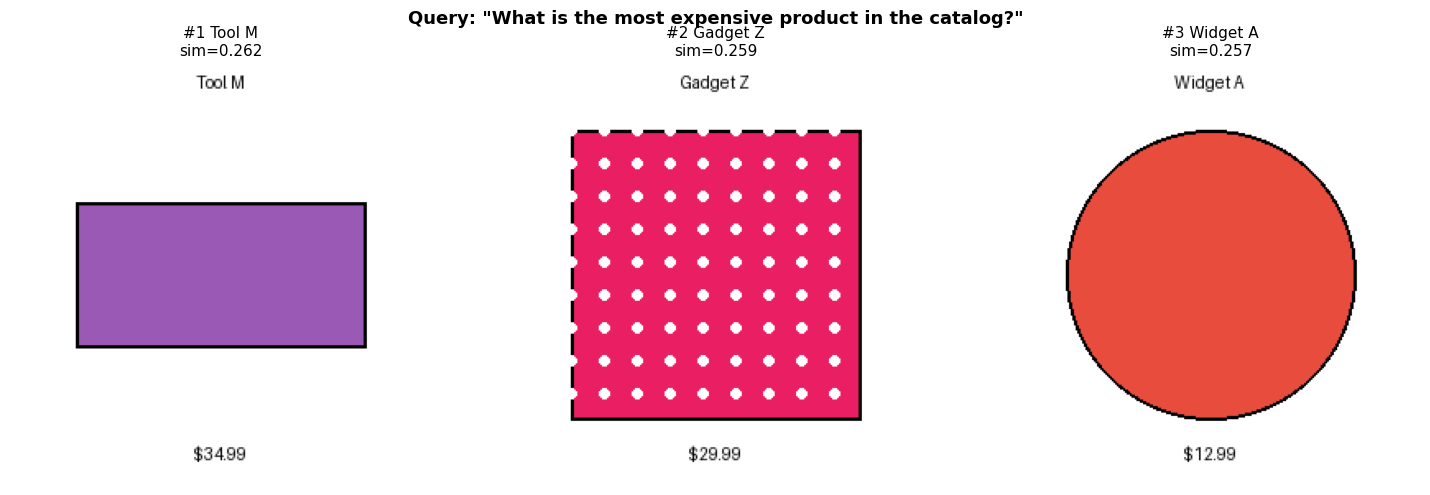


  [WITH IMAGE RAG]
Based on the provided products:
*   **Tool M** costs $34.99
*   **Gadget Z** costs $29.99
*   **Widget A** costs $12.99

The most expensive product in this catalog is **Tool M** at $34.99.
  [Response from Gemini / gemini-2.5-flash]

  [WITHOUT RAG] (provider: Gemini)
I need a bit more information to tell you that!

Which catalog are you referring to?

*   Is it an online store (like Amazon, Apple, Etsy)?
*   A specific company's product list?
*   A physical catalog you're looking at?
*   A particular industry (e.g., luxury goods, cars, art)?

Once you provide more details, I'll do my best to help you find the most expensive item!


In [12]:
questions = [
    "What red products do you have?",
    # "Show me the cheapest circular product.",
   # "Which products have a striped pattern?",
    # "I need a green product. What are my options?",
    "What is the most expensive product in the catalog?",
]


def preview(text, max_len=800):
    text = text or ""
    return text[:max_len] + ("..." if len(text) > max_len else "")


if not has_llm_provider():
    print("Error: No LLM API key configured. Set at least one API key in Colab Secrets.")
else:
    for i, q in enumerate(questions, start=1):
        print("\n" + "=" * 80)
        print(f"Q{i}. {q}\n")

        try:
            answer_rag, retrieved, prov = answer_with_image_rag(q)
            show_retrieval_results(q, retrieved)
            print("\n  [WITH IMAGE RAG]")
            print(preview(answer_rag))
        except Exception as e:
            print(f"  RAG error: {e}")

        try:
            answer_direct, prov_direct = answer_without_rag(q)
            print(f"\n  [WITHOUT RAG] (provider: {prov_direct})")
            print(preview(answer_direct))
        except Exception as e:
            print(f"  Direct error: {e}")

### Checkpoint: Reflection Questions

1. Compare the RAG and non-RAG answers. Which ones hallucinate products that don't exist?
2. How does CLIP's cross-modal embedding enable text-to-image search without manual tagging?
3. What happens when you query for something not in the catalog (e.g., "black hexagonal product")?
4. How does this Image RAG pattern compare to the DBMS RAG and vector-store RAG approaches?

## 8) Interactive Query (Optional)

Use the cell below to ask your own questions against the product image catalog.

Question: What purple or blue products do you have, and which is cheaper?

  [Step 1] Embedding query with CLIP ...
  [Step 2] Retrieved 3 images:
           #1 Tool M (sim=0.297)
           #2 Widget A (sim=0.256)
           #3 Widget B (sim=0.250)
  [Step 3] Generating multimodal answer ...
  [Response from Gemini / gemini-2.5-flash]
  [Step 4] Answer generated (provider: Gemini)


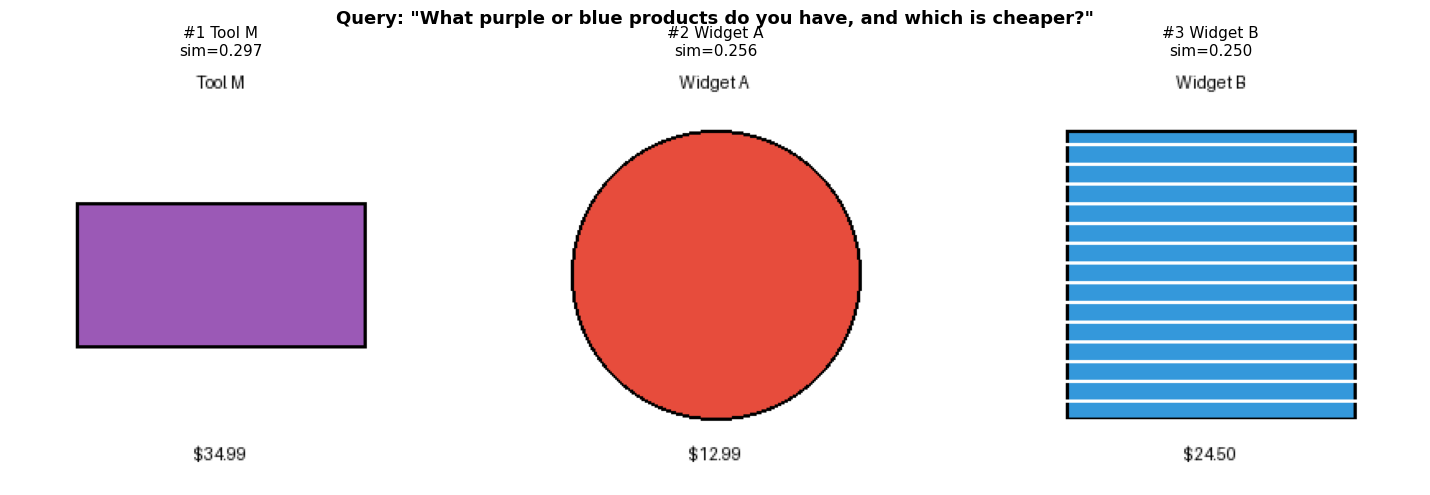


Answer (Gemini):
We have the following purple or blue products:
*   **Tool M:** purple, $34.99
*   **Widget B:** blue, $24.50

Of these, **Widget B** is cheaper at $24.50.


In [13]:
# Change this question to anything you want to ask about the product catalog.
my_question = "What purple or blue products do you have, and which is cheaper?"

if has_llm_provider():
    print(f"Question: {my_question}\n")
    try:
        answer, retrieved, provider = answer_with_image_rag(my_question)
        show_retrieval_results(my_question, retrieved)
        print(f"\nAnswer ({provider}):\n{answer}")
    except Exception as e:
        print(f"Error: {e}")
else:
    print("No LLM API key configured. Set at least one API key in Colab Secrets.")

## 9) Teaching Notes and Exercises

**Key takeaways:**
- RAG extends naturally to images and other modalities via **cross-modal embeddings** like CLIP.
- CLIP embeds text and images into a **shared vector space**, enabling text-to-image retrieval without manual tagging.
- The retrieval step uses the same cosine similarity as document RAG, but operates on image embeddings.
- Multimodal LLMs can directly "see" retrieved images, producing answers grounded on visual evidence.
- Even with synthetic data, the pipeline demonstrates real-world patterns used in e-commerce, medical imaging, and visual search.

**Exercises:**
- Replace the synthetic images with real product photos (e.g., from a Kaggle dataset) and observe how retrieval quality changes.
- Experiment with different CLIP model sizes (`clip-vit-large-patch14`) and compare retrieval accuracy.
- Add more products with similar colors/shapes and test whether the system can still distinguish them.
- Implement a **re-ranking** step where the LLM re-orders retrieved images by relevance before answering.
- Discuss: when would you prefer Image RAG over text-based RAG for a business application?